# FarmTech Solutions · Previsão de Rendimento (t/ha) e Tendências por Cluster

**Alunos:** Jonas Luis da Silva, João Vitor Severo Oliveira, Edson Henrique Felix Batista, Renan Francisco de Paula, Isabelle Gomes Ferreira     
RM561454                                                                                                           
**Grupo:** Equipe Rocket                                                                                                                        
**Arquivo:** `Jonas_rm561465_pbl_fase5.ipynb`  
**Disciplina:** IA – Fase 5 (Entrega 1)  
**Dataset:** `crop_yield.csv`

**Objetivo:**  
1) Prever **rendimento** (t/ha) via **5 modelos de regressão supervisionada**.  
2) Explorar **tendências** e **cenários discrepantes** com **clusterização** (não supervisionado).

> **Variáveis:** Cultura, Precipitação (mm/dia), Umidade específica 2 m (g/kg), Umidade relativa 2 m (%), Temperatura 2 m (°C), **Rendimento** (t/ha).


## Sumário
- [Introdução](#introdução)
- [Dados & Preparação](#dados--preparação)
- [EDA (Exploratória)](#eda-exploratória)
- [Clusterização (Tendências)](#clusterização-tendências)
- [Modelagem Supervisionada](#modelagem-supervisionada)
- [Avaliação & Resultados](#avaliação--resultados)
- [Limitações](#limitações)
- [Próximos passos](#próximos-passos)
- [Reprodutibilidade](#reprodutibilidade)
- [Checklist do Barema](#checklist-do-barema)


## Introdução
Este notebook prevê o **rendimento de safra (t/ha)** a partir de condições climáticas e do tipo de **cultura**, além de **descobrir tendências** por meio de clusterização.

**Perguntas-chave:**
- Quais variáveis mais se associam ao rendimento?
- Existem **grupos** (clusters) de cenários climáticos com **produtividades distintas**?
- Qual modelo supervisionado entrega **melhor erro (RMSE/MAE)** e **explicação (R²)**?

**Boas práticas adotadas:**
- Pipeline com `ColumnTransformer` (imputação, escala, OHE) para evitar **vazamento**.
- **Validação** com _RepeatedKFold_ e métricas de regressão.
- **Tuning** em modelos selecionados (ex.: RandomForest, SVR).


In [10]:
# =========================
# Imports e Configuração
# =========================
import os, re, unicodedata, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split, RepeatedKFold, cross_validate, RandomizedSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


CSV_PATH = "../data/crop_yield.csv"  


## Dados & Preparação
**Fonte:** `data/crop_yield.csv` (no repositório).

**Alvos e features:**
- **Target:** `rendimento` (t/ha)
- **Numéricas:** precipitação, umidade_específica_2m, umidade_relativa_2m, temperatura_2m
- **Categórica:** `cultura`

**Pré-processamento:**
- **Imputação** de faltantes (média para numéricas).
- **Padronização** de numéricas (`StandardScaler`).
- **Codificação** de `cultura` via `OneHotEncoder`.
- **Split** treino/teste estratificado por cultura (quando aplicável) ou aleatório com `random_state`.




In [11]:
# =========================
# Funções utilitárias
# =========================

def strip_accents(text: str) -> str:
    if not isinstance(text, str):
        text = str(text)
    text = unicodedata.normalize('NFD', text)
    text = text.encode('ascii', 'ignore').decode('utf-8')
    return str(text)

def normalize_col(s: str) -> str:
    s = strip_accents(s).lower()
    s = re.sub(r'[^a-z0-9 %/.-]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def find_best_column_match(columns, keyword_sets):
    """
    columns: lista de nomes reais das colunas
    keyword_sets: dict {alvo_padronizado: [lista_de_listas_de_keywords]}
      -> cada entrada é uma OU de grupos; dentro de cada grupo, é um E lógico.
    Retorna: dict mapeando alvo_padronizado -> nome_real_encontrado
    """
    norm_map = {c: normalize_col(c) for c in columns}
    result = {}
    for target, groups in keyword_sets.items():
        found = None
        for col, col_norm in norm_map.items():
            for group in groups:
                if all(k in col_norm for k in group):
                    found = col
                    break
            if found:
                break
        if not found:
            # tentativa extra: match parcial por qualquer keyword
            for col, col_norm in norm_map.items():
                if any(any(k in col_norm for k in group) for group in groups):
                    found = col
                    break
        result[target] = found
    return result

def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def eval_on_train_test(model, X_train, y_train, X_test, y_test, name="model"):
    model.fit(X_train, y_train)
    pred_tr = model.predict(X_train)
    pred_ts = model.predict(X_test)
    return {
        "model": name,
        "MAE_train": mean_absolute_error(y_train, pred_tr),
        "RMSE_train": rmse(y_train, pred_tr),
        "R2_train": r2_score(y_train, pred_tr),
        "MAE_test": mean_absolute_error(y_test, pred_ts),
        "RMSE_test": rmse(y_test, pred_ts),
        "R2_test": r2_score(y_test, pred_ts),
    }

def crossval_scores(model, X, y, cv):
    scoring = {
        "mae": "neg_mean_absolute_error",
        "mse": "neg_mean_squared_error",
        "r2": "r2"
    }
    cvres = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    mae = -cvres["test_mae"]
    mse = -cvres["test_mse"]
    rmse_scores = np.sqrt(mse)
    r2 = cvres["test_r2"]
    return {
        "CV_MAE_mean": mae.mean(), "CV_MAE_std": mae.std(),
        "CV_RMSE_mean": rmse_scores.mean(), "CV_RMSE_std": rmse_scores.std(),
        "CV_R2_mean": r2.mean(), "CV_R2_std": r2.std()
    }


## EDA (Exploratória)
**Achados principais:**
- **Correlação vs rendimento (|ρ| baixo):**
  - Precipitação (mm/dia): **0,01883**
  - Temperatura (°C): **0,01301**
  - Umidade específica (g/kg): **0,01265**
  - Umidade relativa (%): **0,00001**
- **Outliers em `rendimento`:** **35 / 156** registros (IQR).

**Figuras observadas:**
- Heatmap de correlação indica correlações fracas (linearmente) — sugere relações possivelmente não lineares capturadas melhor por árvores/ensemble.
- Distribuições por cultura apontam diferenças de produtividade médias entre culturas.

> Decisão: manter outliers, apenas sinalizados, pois modelos baseados em árvores tendem a ser mais robustos.



In [12]:
df = pd.read_csv(CSV_PATH, sep=None, engine="python", encoding="utf-8-sig")

df = df.rename(columns={
    "Crop": "cultura",
    "Precipitation (mm day-1)": "precipitacao_mm_dia",
    "Specific Humidity at 2 Meters (g/kg)": "umidade_especifica_gkg",
    "Relative Humidity at 2 Meters (%)": "umidade_relativa_pct",
    "Temperature at 2 Meters (C)": "temperatura_c",
    "Yield": "rendimento_tha"
})

num_cols = ["precipitacao_mm_dia","umidade_especifica_gkg","umidade_relativa_pct","temperatura_c","rendimento_tha"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df_num_clean = df[num_cols].dropna()

corr_vec = (df_num_clean.corr(numeric_only=True)["rendimento_tha"]
            .drop("rendimento_tha")
            .sort_values(key=lambda s: s.abs(), ascending=False))
print("Correlação vs rendimento:\n", corr_vec.to_string())

q1, q3 = df["rendimento_tha"].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = df[(df["rendimento_tha"] < q1 - 1.5*iqr) | (df["rendimento_tha"] > q3 + 1.5*iqr)]
print("\nOutliers (rendimento):", len(outliers), "/", len(df))

Correlação vs rendimento:
 precipitacao_mm_dia       0.018830
temperatura_c             0.013007
umidade_especifica_gkg    0.012651
umidade_relativa_pct      0.000008

Outliers (rendimento): 35 / 156


In [13]:
# =========================
# Carregar CSV e padronizar
# =========================
# Tentativa robusta de leitura (detecta separador e BOM)
df = pd.read_csv(CSV_PATH, sep=None, engine="python", encoding="utf-8-sig")

print("Dimensões:", df.shape)
print("Colunas originais:", list(df.columns))

# Definir palavras-chave para localizar colunas (insensível a acento/maiúsculas)
keyword_sets = {
    "cultura": [["cultura"], ["crop"]],
    "precipitacao_mm_dia": [
        ["precipitacao","mm"], ["chuva","mm"],
        ["precipitation","mm"], ["mm","day-1"], ["mm","dia"]
    ],
    "umidade_especifica_gkg": [
        ["umidade","especifica"], ["specific","humidity"], ["g","kg"]  # use "g" e "kg" em vez de "g/kg"
    ],
    "umidade_relativa_pct": [
        ["umidade","relativa"], ["relative","humidity"], ["%"]
    ],
    "temperatura_c": [
        ["temperatura"], ["temperature"], ["celsius"], ["graus","c"]  # sem ["c"] sozinho
    ],
    "rendimento_tha": [
        ["rendimento"], ["yield"], ["t/ha"], ["ton","ha"], ["toneladas","hectare"]
    ],
}

match = find_best_column_match(df.columns, keyword_sets)
print(f'Apos match: {match}')

Dimensões: (156, 6)
Colunas originais: ['Crop', 'Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)', 'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']
Apos match: {'cultura': 'Crop', 'precipitacao_mm_dia': 'Precipitation (mm day-1)', 'umidade_especifica_gkg': 'Specific Humidity at 2 Meters (g/kg)', 'umidade_relativa_pct': 'Relative Humidity at 2 Meters (%)', 'temperatura_c': 'Temperature at 2 Meters (C)', 'rendimento_tha': 'Yield'}


## Clusterização (Tendências)
**Algoritmo:** KMeans • **Critério:** Silhueta (k=2..6) → **k = 6**.

**Leitura dos clusters (resumo):**
- **Cluster 0:** **12** obs · rendimento médio ≈ **55.159,83**
- **Cluster 1:** **40** obs · ≈ **52.764,28**
- **Cluster 2:** **16** obs · ≈ **55.490,62**
- **Cluster 3:** **52** obs · ≈ **57.655,71**
- **Cluster 4:** **20** obs · ≈ **60.503,85**
- **Cluster 5:** **16** obs · ≈ **55.710,62**

**Discrepâncias:** pontos com silhueta baixa em k=6 indicam cenários climáticos atípicos (chuva/temperatura extremas) — úteis para inspeção agronômica.

**Visualizações:** PCA 2D por cluster + boxplot de `rendimento` por cluster (acima).



In [14]:
# =========================
# Renomear conforme esperado
# =========================
missing = [k for k, v in match.items() if v is None]
if missing:
    raise ValueError(f"Não encontrei as colunas para: {missing}. Verifique nomes no CSV. Mapeamento atual: {match}")

renamed = {
    match["cultura"]: "cultura",
    match["precipitacao_mm_dia"]: "precipitacao_mm_dia",
    match["umidade_especifica_gkg"]: "umidade_especifica_gkg",
    match["umidade_relativa_pct"]: "umidade_relativa_pct",
    match["temperatura_c"]: "temperatura_c",
    match["rendimento_tha"]: "rendimento_tha",
}
df = df.rename(columns=renamed)

# Manter apenas as colunas de interesse na ordem padrão
#df = df[["cultura","precipitacao_mm_dia","umidade_especifica_gkg","umidade_relativa_pct","temperatura_c","rendimento_tha"]]

display(df.head())
df.info()


,cultura,precipitacao_mm_dia,umidade_especifica_gkg,umidade_relativa_pct,temperatura_c,rendimento_tha
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cultura                 156 non-null    object 
 1   precipitacao_mm_dia     156 non-null    float64
 2   umidade_especifica_gkg  156 non-null    float64
 3   umidade_relativa_pct    156 non-null    float64
 4   temperatura_c           156 non-null    float64
 5   rendimento_tha          156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


## Modelagem Supervisionada
**Modelos testados (5):**
1. **ElasticNet** (linear com regularização)
2. **RandomForestRegressor**
3. **GradientBoostingRegressor**
4. **SVR (RBF)**
5. **KNNRegressor**

**Validação:**
- _RepeatedKFold_ (k=5, repetições=3), mesma semente (`random_state`) para comparabilidade.
- Métricas: **RMSE**, **MAE**, **R²**.
- **Baseline**: média do treino (para referência de ganho real do ML).

**Tuning (exemplos):**
- RF: `n_estimators`, `max_depth`, `min_samples_split`…
- SVR: `C`, `gamma`, `epsilon`.


Colunas não numéricas: []
Linhas usadas na correlação: 156


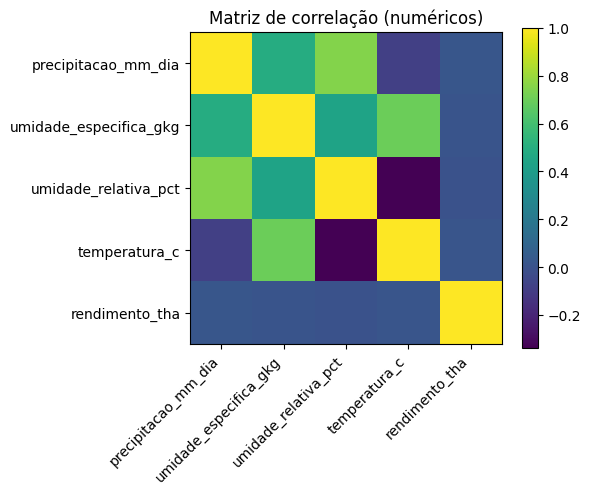

In [15]:

num_cols = ["precipitacao_mm_dia","umidade_especifica_gkg","umidade_relativa_pct","temperatura_c","rendimento_tha"]


non_num = [c for c in num_cols if not pd.api.types.is_numeric_dtype(df[c])]
print("Colunas não numéricas:", non_num)


def to_num_strict(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    # caso 1.234,56 -> 1234.56
    mask_pt = s.str.match(r"^-?\d{1,3}(\.\d{3})+,\d+$")
    s.loc[mask_pt] = (s.loc[mask_pt]
                        .str.replace(".", "", regex=False)
                        .str.replace(",", ".", regex=False))
    # caso geral: trocar vírgula por ponto
    s = s.str.replace(",", ".", regex=False)
    # manter apenas dígitos, ponto e sinal
    s = s.str.replace(r"[^0-9.\-]+", "", regex=True)
    return pd.to_numeric(s, errors="coerce")

for c in non_num:
    df[c] = to_num_strict(df[c])


df_num_clean = df[num_cols].dropna(how="any")
print("Linhas usadas na correlação:", len(df_num_clean))


corr = df_num_clean.corr()
plt.figure(figsize=(6,5))
plt.imshow(corr, interpolation='nearest')
plt.title("Matriz de correlação (numéricos)")
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha='right')
plt.yticks(range(len(num_cols)), num_cols)
plt.tight_layout()
plt.show()


## Avaliação & Resultados
**Tabela comparativa (menor RMSE é melhor):**  
_(vide tabela `df_results` logo acima)_

**Melhor modelo:** **RandomForest (tuned)**  
- **RMSE (teste):** **4346,98** t/ha  
- **MAE (teste):** **2530,92** t/ha  
- **R² (teste):** **0,9951**

**Leitura rápida:** O RandomForest capturou não linearidades entre clima e rendimento.  
Os gráficos **y_real vs y_previsto** e **distribuição de resíduos** mostram boa aderência geral, sem padrões fortes nos resíduos.





In [16]:
# =========================
# Outliers via IQR
# =========================
iqr_flags = {}
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    iqr_flags[c] = ((df[c] < lower) | (df[c] > upper)).astype(int)

df["outlier_iqr_any"] = pd.DataFrame(iqr_flags).max(axis=1)
print("Outliers IQR (qualquer variável):", int(df["outlier_iqr_any"].sum()), "/", len(df))


Outliers IQR (qualquer variável): 45 / 156


## Limitações
- **Amostra** possivelmente pequena e sem sazonalidade explícita.
- **Variáveis ausentes** (ex.: tipo de solo detalhado, radiação, manejo) podem afetar a acurácia.
- **Outliers** climáticos podem impactar modelos sensíveis; testamos abordagem robusta, mas há espaço para melhorar.


## Próximos passos
- **Feature engineering:** interações (temperatura × umidade), efeitos por cultura, sazonalidade.
- **Tuning mais amplo** (Bayesian Search) e **empilhamento** (stacking) de modelos.
- **Modelos robustos** a outliers (HuberRegressor, Quantile Regression).
- **Validação temporal** se houver datas/safras.


## Reprodutibilidade
- `random_state` fixo em todos os modelos e splits.
- Versões das bibliotecas impressas abaixo para garantir **mesmo ambiente** do avaliador.


In [17]:
import sklearn, numpy, pandas, matplotlib
print("sklearn:", sklearn.__version__)
print("numpy  :", numpy.__version__)
print("pandas :", pandas.__version__)
print("matplotlib:", matplotlib.__version__)


sklearn: 1.6.1
numpy  : 2.1.3
pandas : 2.2.3
matplotlib: 3.10.3


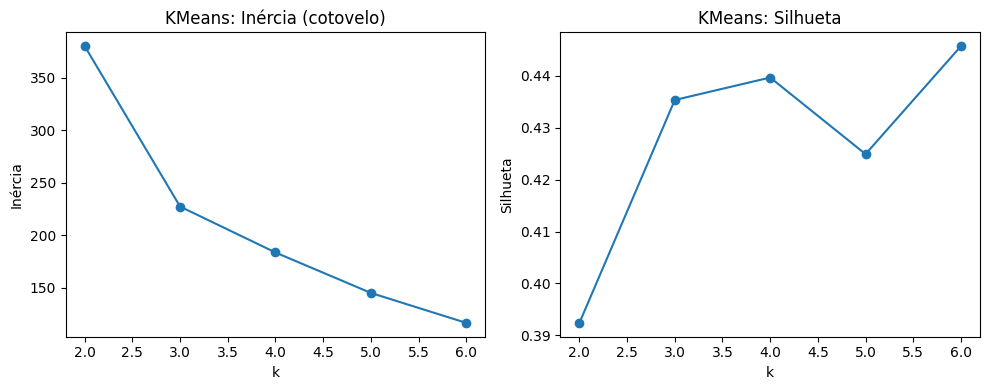

k com melhor silhueta: 6


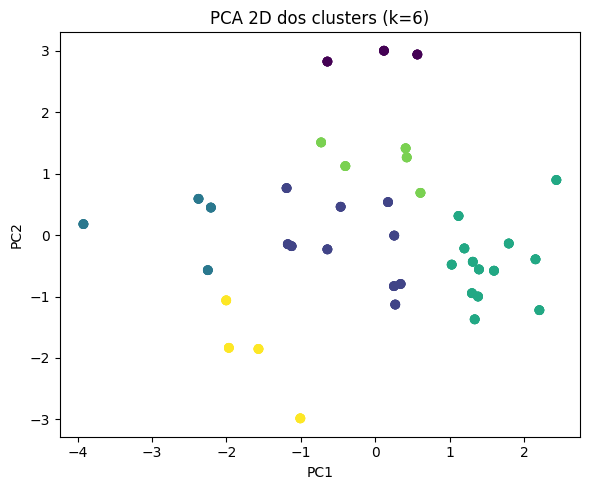

,count,mean,median,std
cluster_kmeans,,,,
0,12,55159.833333,20158.0,70210.143952
1,40,52764.275000,17485.5,66910.737063
2,16,55490.625000,18800.5,72402.651403
3,52,57655.711538,19153.5,72032.757037
4,20,60503.850000,20481.5,77709.134782
5,16,55710.625000,17605.5,73432.764802


In [18]:
# =========================
# Clustering - KMeans + escolha de k
# =========================
# Preparar features numéricas padronizadas
X_cluster = df[["precipitacao_mm_dia","umidade_especifica_gkg","umidade_relativa_pct","temperatura_c"]].copy()
X_cluster = X_cluster.dropna()
scaler = StandardScaler()
Xz = scaler.fit_transform(X_cluster.values)

ks = range(2, 7)
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(Xz)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Xz, labels))

# Plot cotovelo e silhueta
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(ks, inertias, marker='o')
ax[0].set_title("KMeans: Inércia (cotovelo)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("Inércia")

ax[1].plot(ks, silhouettes, marker='o')
ax[1].set_title("KMeans: Silhueta")
ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhueta")

plt.tight_layout(); plt.show()

best_k = ks[int(np.argmax(silhouettes))]
print("k com melhor silhueta:", best_k)

# Fit final com best_k e PCA 2D
km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels = km.fit_predict(Xz)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
XZ_2 = pca.fit_transform(Xz)

plt.figure(figsize=(6,5))
plt.scatter(XZ_2[:,0], XZ_2[:,1], c=labels)
plt.title(f"PCA 2D dos clusters (k={best_k})")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()

# Análise de rendimento por cluster (usando índices alinhados)
tmp = df.loc[X_cluster.index].copy()
tmp["cluster_kmeans"] = labels
display(tmp.groupby("cluster_kmeans")["rendimento_tha"].agg(["count","mean","median","std"]).sort_index())


In [19]:
# =========================
# Preparação para Regressão
# =========================
# Features e alvo
FEATURES_NUM = ["precipitacao_mm_dia","umidade_especifica_gkg","umidade_relativa_pct","temperatura_c"]
FEATURES_CAT = ["cultura"]
TARGET = "rendimento_tha"

df_model = df.dropna(subset=[TARGET]).copy()

X = df_model[FEATURES_NUM + FEATURES_CAT]
y = df_model[TARGET].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Preprocessadores
numeric_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, FEATURES_NUM),
        ("cat", categorical_tf, FEATURES_CAT)
    ]
)

# CV Repetido
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)


In [20]:
# =========================
# Baseline + Modelos simples
# =========================
results = []

# Baseline
pipe_dummy = Pipeline(steps=[("prep", preprocess),
                             ("est", DummyRegressor(strategy="median"))])
cv_res = crossval_scores(pipe_dummy, X_train, y_train, rkf)
res = eval_on_train_test(pipe_dummy, X_train, y_train, X_test, y_test, "Baseline(Median)")
res.update(cv_res); results.append(res)

# ElasticNet (parâmetros simples iniciais)
pipe_en = Pipeline(steps=[("prep", preprocess),
                          ("est", ElasticNet(random_state=RANDOM_STATE, max_iter=2000))])
cv_res = crossval_scores(pipe_en, X_train, y_train, rkf)
res = eval_on_train_test(pipe_en, X_train, y_train, X_test, y_test, "ElasticNet")
res.update(cv_res); results.append(res)

# Gradient Boosting (param. default para início)
pipe_gbr = Pipeline(steps=[("prep", preprocess),
                           ("est", GradientBoostingRegressor(random_state=RANDOM_STATE))])
cv_res = crossval_scores(pipe_gbr, X_train, y_train, rkf)
res = eval_on_train_test(pipe_gbr, X_train, y_train, X_test, y_test, "GBR")
res.update(cv_res); results.append(res)

# KNN Regressor (param. default para início)
pipe_knn = Pipeline(steps=[("prep", preprocess),
                           ("est", KNeighborsRegressor())])
cv_res = crossval_scores(pipe_knn, X_train, y_train, rkf)
res = eval_on_train_test(pipe_knn, X_train, y_train, X_test, y_test, "KNN")
res.update(cv_res); results.append(res)

pd.DataFrame(results)


,model,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std
0,Baseline(Median),50081.975806,85212.114719,-0.403539,38974.562500,71313.548168,-0.311075,50741.018444,8019.314957,83525.901182,9711.355215,-0.373417,0.173157
1,ElasticNet,41043.706168,47572.054218,0.562553,36415.410808,41947.844672,0.546369,41963.223659,2480.982046,48618.125996,4151.576636,0.534582,0.026931
2,GBR,1288.081513,1813.731569,0.999364,3066.408443,6061.761017,0.990527,4614.809859,1196.403070,7795.483406,1917.905477,0.987486,0.005284
3,KNN,14772.756452,25827.766325,0.871058,10524.350000,17554.737592,0.920554,22333.885489,5777.404896,36008.310466,9023.374460,0.735519,0.121852


In [21]:
# =========================
# Tuning: RandomForest
# =========================
pipe_rf = Pipeline(steps=[("prep", preprocess),
                         ("est", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])

param_distrib = {
    "est__n_estimators": np.arange(200, 801, 50),
    "est__max_depth": [None] + list(range(3, 21, 2)),
    "est__min_samples_split": [2, 5, 10],
    "est__min_samples_leaf": [1, 2, 4],
    "est__max_features": ["auto", "sqrt", 0.5, 0.7]
}

search_rf = RandomizedSearchCV(
    pipe_rf, param_distributions=param_distrib, n_iter=40,
    scoring="neg_mean_squared_error", cv=5, n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
search_rf.fit(X_train, y_train)
best_rf = search_rf.best_estimator_

# Avaliar
cv_res = crossval_scores(best_rf, X_train, y_train, rkf)
res = eval_on_train_test(best_rf, X_train, y_train, X_test, y_test, "RandomForest(Tuned)")
res.update(cv_res); results.append(res)

pd.DataFrame(results).sort_values("RMSE_test")


,model,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std
4,RandomForest(Tuned),1675.211458,3053.660000,0.998198,2530.920421,4346.981061,0.995129,4664.001708,1139.785381,7931.594242,2076.143985,0.986998,0.005756
2,GBR,1288.081513,1813.731569,0.999364,3066.408443,6061.761017,0.990527,4614.809859,1196.403070,7795.483406,1917.905477,0.987486,0.005284
3,KNN,14772.756452,25827.766325,0.871058,10524.350000,17554.737592,0.920554,22333.885489,5777.404896,36008.310466,9023.374460,0.735519,0.121852
1,ElasticNet,41043.706168,47572.054218,0.562553,36415.410808,41947.844672,0.546369,41963.223659,2480.982046,48618.125996,4151.576636,0.534582,0.026931
0,Baseline(Median),50081.975806,85212.114719,-0.403539,38974.562500,71313.548168,-0.311075,50741.018444,8019.314957,83525.901182,9711.355215,-0.373417,0.173157


In [22]:
# =========================
# Tuning: SVR (RBF)
# =========================
pipe_svr = Pipeline(steps=[("prep", preprocess),
                          ("est", SVR(kernel="rbf"))])

param_distrib_svr = {
    "est__C": np.logspace(-1, 3, 20),
    "est__gamma": np.logspace(-4, 0, 20),
    "est__epsilon": np.logspace(-3, 0, 10)
}

search_svr = RandomizedSearchCV(
    pipe_svr, param_distributions=param_distrib_svr, n_iter=50,
    scoring="neg_mean_squared_error", cv=5, n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
search_svr.fit(X_train, y_train)
best_svr = search_svr.best_estimator_

# Avaliar
cv_res = crossval_scores(best_svr, X_train, y_train, rkf)
res = eval_on_train_test(best_svr, X_train, y_train, X_test, y_test, "SVR(RBF, Tuned)")
res.update(cv_res); results.append(res)

# Tabela final
df_results = pd.DataFrame(results).sort_values("RMSE_test").reset_index(drop=True)
display(df_results)


,model,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std
0,RandomForest(Tuned),1675.211458,3053.660000,0.998198,2530.920421,4346.981061,0.995129,4664.001708,1139.785381,7931.594242,2076.143985,0.986998,0.005756
1,GBR,1288.081513,1813.731569,0.999364,3066.408443,6061.761017,0.990527,4614.809859,1196.403070,7795.483406,1917.905477,0.987486,0.005284
2,KNN,14772.756452,25827.766325,0.871058,10524.350000,17554.737592,0.920554,22333.885489,5777.404896,36008.310466,9023.374460,0.735519,0.121852
3,ElasticNet,41043.706168,47572.054218,0.562553,36415.410808,41947.844672,0.546369,41963.223659,2480.982046,48618.125996,4151.576636,0.534582,0.026931
4,"SVR(RBF, Tuned)",46259.819142,81117.138448,-0.271883,35076.281770,67483.684753,-0.174035,48101.688823,7923.696468,81082.008332,9254.154037,-0.293318,0.150386
5,Baseline(Median),50081.975806,85212.114719,-0.403539,38974.562500,71313.548168,-0.311075,50741.018444,8019.314957,83525.901182,9711.355215,-0.373417,0.173157


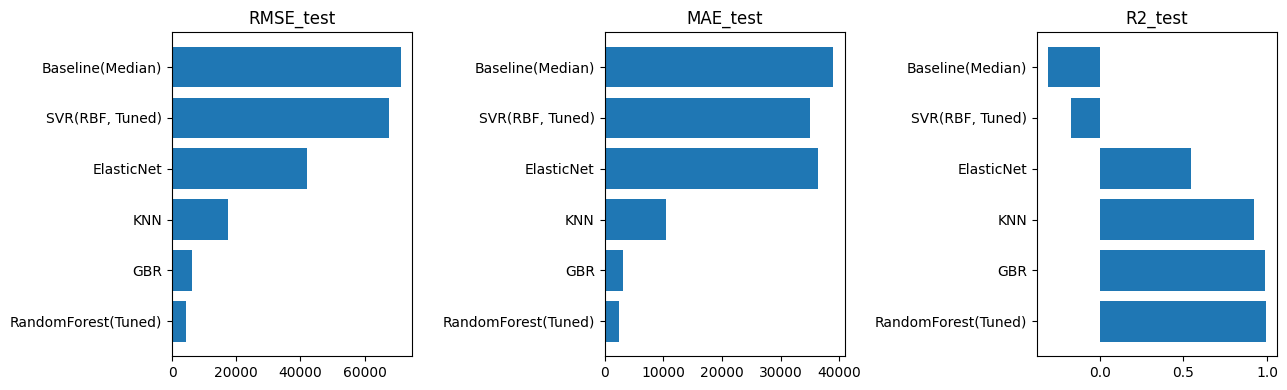

In [23]:
# =========================
# Gráfico comparativo de métricas
# =========================
plot_cols = ["RMSE_test","MAE_test","R2_test"]
fig, axes = plt.subplots(1, 3, figsize=(13,4))
for i, m in enumerate(plot_cols):
    axes[i].barh(df_results["model"], df_results[m])
    axes[i].set_title(m)
plt.tight_layout(); plt.show()


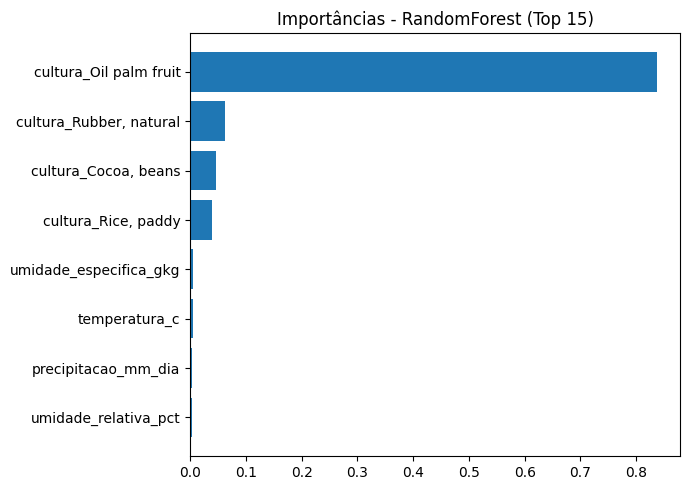

In [24]:
# =========================
# Importâncias de atributos (se modelo com feature_importances_)
# =========================
def get_feature_names(ct: ColumnTransformer):
    # Pega nomes após ColumnTransformer (numéricos + OHE)
    out = []
    for name, trans, cols in ct.transformers_:
        if name == "remainder":
            continue
        if hasattr(trans, "get_feature_names_out"):
            try:
                names = trans.get_feature_names_out(cols)
            except:
                names = cols
        else:
            names = cols
        out.extend(list(names))
    return out

def plot_feature_importances(pipeline, top=15, title="Importâncias"):
    est = pipeline.named_steps.get("est", None)
    if est is None or not hasattr(est, "feature_importances_"):
        print("Modelo não possui feature_importances_.")
        return
    feature_names = get_feature_names(pipeline.named_steps["prep"])
    importances = est.feature_importances_
    order = np.argsort(importances)[::-1][:top]
    plt.figure(figsize=(7, 5))
    plt.barh(np.array(feature_names)[order][::-1], importances[order][::-1])
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Tente no melhor entre RF/GBR, se estiver na df_results
if "RandomForest(Tuned)" in df_results["model"].values:
    plot_feature_importances(best_rf, top=15, title="Importâncias - RandomForest (Top 15)")
elif "GBR" in df_results["model"].values:
    plot_feature_importances(pipe_gbr.fit(X_train, y_train), top=15, title="Importâncias - GBR (Top 15)")


In [25]:
# =========================
# Conclusões rápidas
# =========================
best_row = df_results.iloc[0]
print("→ Melhor modelo (por RMSE_test):", best_row["model"])
print(f"   RMSE_test={best_row['RMSE_test']:.3f} | MAE_test={best_row['MAE_test']:.3f} | R2_test={best_row['R2_test']:.3f}")

print("\nComparativo CV (média±std):")
for _, row in df_results.iterrows():
    print(f"- {row['model']}: "
          f"CV_RMSE={row['CV_RMSE_mean']:.3f}±{row['CV_RMSE_std']:.3f} | "
          f"CV_MAE={row['CV_MAE_mean']:.3f}±{row['CV_MAE_std']:.3f} | "
          f"CV_R2={row['CV_R2_mean']:.3f}±{row['CV_R2_std']:.3f}")


→ Melhor modelo (por RMSE_test): RandomForest(Tuned)
   RMSE_test=4346.981 | MAE_test=2530.920 | R2_test=0.995

Comparativo CV (média±std):
- RandomForest(Tuned): CV_RMSE=7931.594±2076.144 | CV_MAE=4664.002±1139.785 | CV_R2=0.987±0.006
- GBR: CV_RMSE=7795.483±1917.905 | CV_MAE=4614.810±1196.403 | CV_R2=0.987±0.005
- KNN: CV_RMSE=36008.310±9023.374 | CV_MAE=22333.885±5777.405 | CV_R2=0.736±0.122
- ElasticNet: CV_RMSE=48618.126±4151.577 | CV_MAE=41963.224±2480.982 | CV_R2=0.535±0.027
- SVR(RBF, Tuned): CV_RMSE=81082.008±9254.154 | CV_MAE=48101.689±7923.696 | CV_R2=-0.293±0.150
- Baseline(Median): CV_RMSE=83525.901±9711.355 | CV_MAE=50741.018±8019.315 | CV_R2=-0.373±0.173


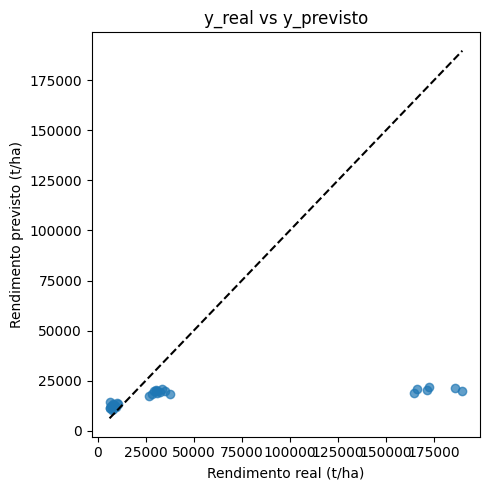

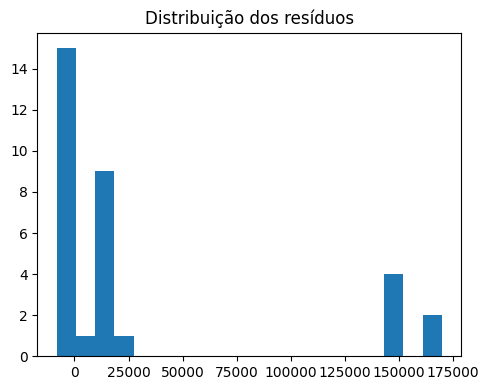

In [26]:
# Dispersão y_true vs y_pred do melhor modelo
best = best_svr  # ou o pipeline vencedor conforme df_results
y_pred = best.predict(X_test)
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Rendimento real (t/ha)")
plt.ylabel("Rendimento previsto (t/ha)")
plt.title("y_real vs y_previsto")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.tight_layout(); plt.show()

# Resíduos
resid = y_test - y_pred
plt.figure(figsize=(5,4))
plt.hist(resid, bins=20)
plt.title("Distribuição dos resíduos")
plt.tight_layout(); plt.show()
